# Day 38 (2/3) — Perceptron Trick with Sigmoid

**Goal:** see how replacing the **step** function with the **sigmoid** turns the perceptron into logistic regression.

**In this notebook**
1. Understand the sigmoid function
2. Train the step perceptron and sklearn's `LogisticRegression` (baseline)
3. Train the sigmoid perceptron and compare all three boundaries

> 📖 Theory: [`theory.md`](theory.md) §4–5

## Step 0 — The sigmoid function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

It squashes any number into $(0, 1)$, so its output can be read as a probability, and $\sigma(0) = 0.5$ exactly on the boundary.

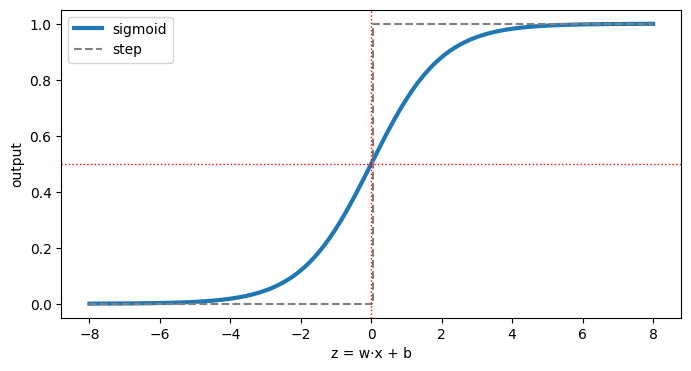

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)
plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z), linewidth=3, label='sigmoid')
plt.step(z, (z > 0).astype(int), where='post', linestyle='--', color='gray', label='step')
plt.axhline(0.5, color='red', linewidth=1, linestyle=':')
plt.axvline(0, color='red', linewidth=1, linestyle=':')
plt.xlabel('z = w·x + b')
plt.ylabel('output')
plt.legend()
plt.show()

The step function only says **yes / no**. The sigmoid says **how sure**: a point barely on the correct side gets ≈ 0.6, a point far away gets ≈ 1.

## Step 1 — Create a 2-class dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,
                           hypercube=False, class_sep=30)
print(X.shape, np.bincount(y))

(100, 2) [50 50]


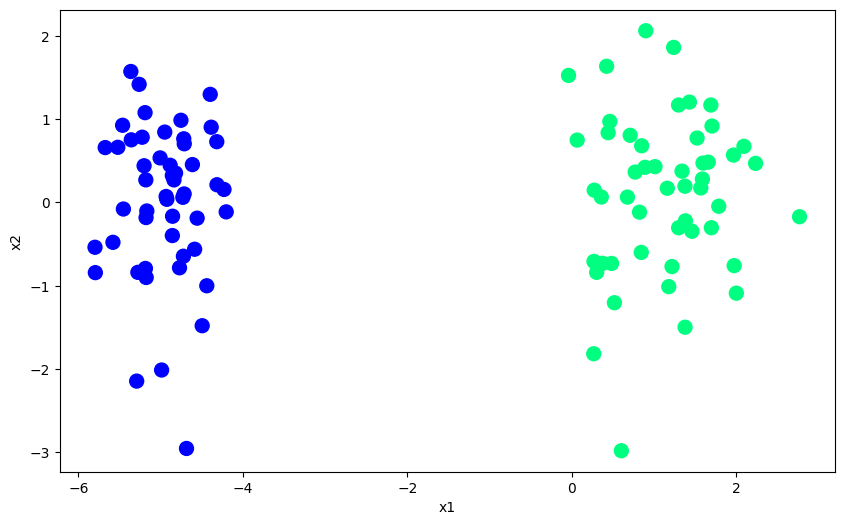

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

## Step 2 — Baseline 1: the step perceptron (from notebook 01)

In [4]:
def step(z):
    return 1 if z > 0 else 0


def perceptron(X, y, activation, lr=0.1, epochs=1000, seed=0):
    rng = np.random.default_rng(seed)
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])

    for i in range(epochs):
        j = rng.integers(0, X.shape[0])
        y_hat = activation(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

The `activation` argument lets us run the **same** algorithm with `step` now and `sigmoid` later; that one swap is the only difference.

In [5]:
intercept_, coef_ = perceptron(X, y, activation=step)
print("coef_     :", coef_)
print("intercept_:", intercept_)

coef_     : [1.08682872 0.52024363]
intercept_: 1.2000000000000002


In [6]:
def boundary_line(intercept, coef, x_range=np.linspace(-3, 3, 100)):
    """Points on w1*x1 + w2*x2 + b = 0, i.e. x2 = -(w1/w2)*x1 - b/w2  (theory §2)."""
    m = -(coef[0] / coef[1])
    c = -(intercept / coef[1])
    return x_range, m * x_range + c

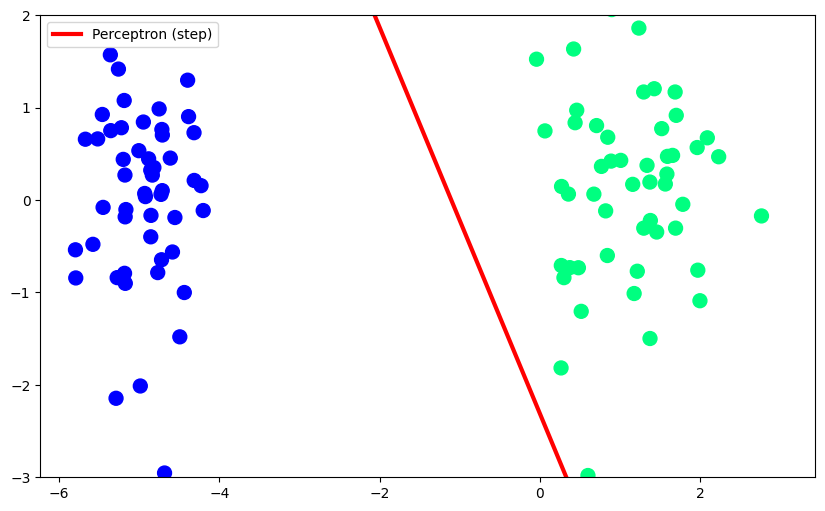

In [7]:
x_p, y_p = boundary_line(intercept_, coef_)

plt.figure(figsize=(10, 6))
plt.plot(x_p, y_p, color='red', linewidth=3, label='Perceptron (step)')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.show()

## Step 3 — Baseline 2: scikit-learn `LogisticRegression`

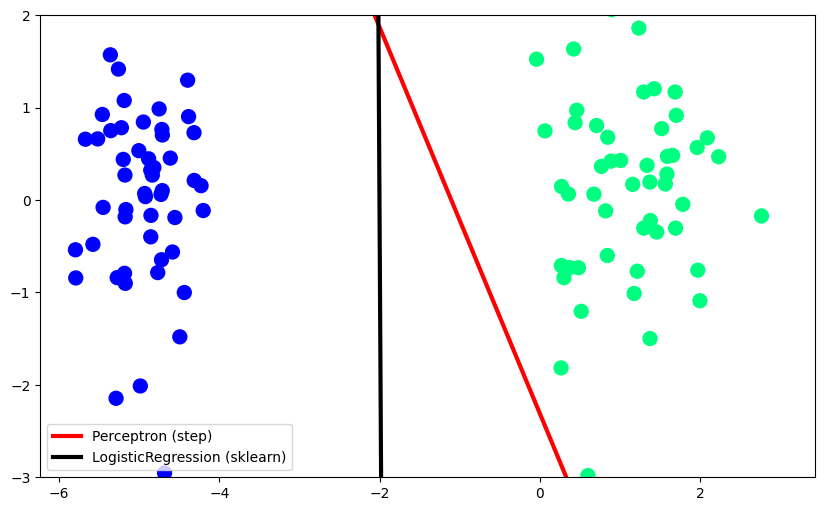

In [8]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression()
lor.fit(X, y)
x_l, y_l = boundary_line(lor.intercept_[0], lor.coef_[0])

plt.figure(figsize=(10, 6))
plt.plot(x_p, y_p, color='red', linewidth=3, label='Perceptron (step)')
plt.plot(x_l, y_l, color='black', linewidth=3, label='LogisticRegression (sklearn)')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.show()

## Step 4 — The sigmoid perceptron

Same loop, but $\hat y = \sigma(w \cdot x)$. Now $(y - \hat y)$ is **never exactly 0**:

| Point | $y$ | $\hat y$ | $y - \hat y$ | Effect |
|---|---|---|---|---|
| misclassified | 1 | 0.2 | +0.8 | strong pull to fix it |
| correct, near the line | 1 | 0.6 | +0.4 | pushes the line **away** |
| correct, far from the line | 1 | 0.999 | ≈ 0 | almost no effect |

So the line keeps moving until it sits comfortably between both classes.

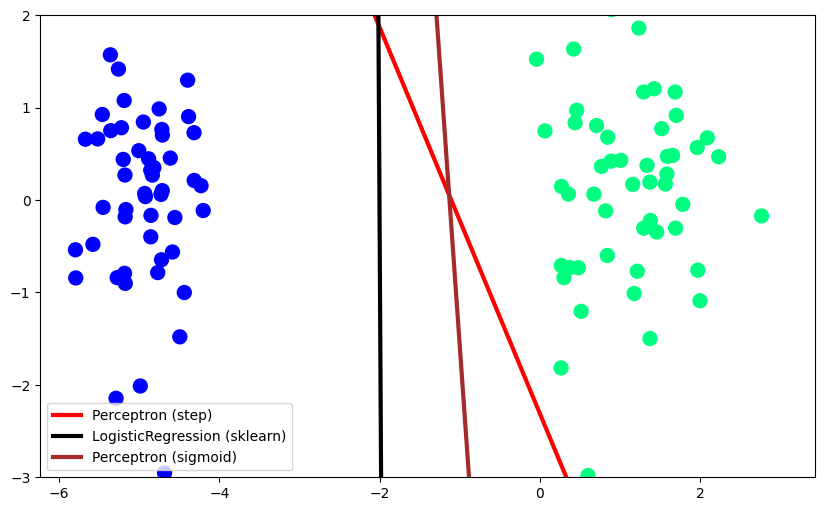

In [9]:
intercept_s, coef_s = perceptron(X, y, activation=sigmoid)
x_s, y_s = boundary_line(intercept_s, coef_s)

plt.figure(figsize=(10, 6))
plt.plot(x_p, y_p, color='red', linewidth=3, label='Perceptron (step)')
plt.plot(x_l, y_l, color='black', linewidth=3, label='LogisticRegression (sklearn)')
plt.plot(x_s, y_s, color='brown', linewidth=3, label='Perceptron (sigmoid)')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.show()

**Observation.** The sigmoid version (brown) moves away from the edge of the cluster and toward the sklearn line (black).
It is still not identical: it uses one random point per update and a fixed number of steps, while sklearn
minimises the full log-loss with an exact optimiser and adds L2 regularisation (theory §8).

### Probabilities, not just labels
With a sigmoid, the model outputs $P(y = 1 \mid x)$:

In [10]:
points = X[:5]
z_scores = intercept_s + points @ coef_s
print(np.c_[points.round(2), sigmoid(z_scores).round(3), y[:5]])
print("columns: x1, x2, P(y=1), true y")

[[ 0.82  -0.12   0.988  1.   ]
 [ 0.38  -0.73   0.964  1.   ]
 [ 0.27  -0.71   0.955  1.   ]
 [-4.99  -2.01   0.     0.   ]
 [ 0.42   1.63   0.979  1.   ]]
columns: x1, x2, P(y=1), true y


### Key takeaways
- Step → sigmoid is the only change, but every point now contributes, weighted by how wrong or close it is.
- The result is a better-placed boundary **plus probabilities**.
- This update rule $w \leftarrow w + \eta (y - \sigma(w \cdot x))\,x$ is exactly **stochastic gradient descent on log-loss** (theory §7).

➡️ Next: **`03-gradient-descent.ipynb`** derives that properly and trains with batch gradient descent.